# VOCALS-REx retrieval with pydisort_riccati_jax

The ultimate goal is to **retrieve an effective-radius profile $r_e(\tau)$** from VOCALS-REx marine stratocumulus, using the fully differentiable chain

$$ r_e(\tau)\xrightarrow{\;\texttt{miejax\_lite}\;}\big(\omega(\tau),\,\text{Leg\_coeffs}(\tau)\big)\xrightarrow{\;\texttt{pydisort\_riccati\_jax}\;} u^{+}(\tau{=}0,\mu,\phi). $$

VOCALS stratocumulus has $r_e\approx 4$–$17\,\mu\mathrm{m}$, observed in the MODIS bands 0.645 / 1.64 / **2.13** µm (2.13 µm is the most absorbing, where $\omega<1$ carries the size signal), with $\tau$ up to $\sim30$ over a low-albedo ocean ($\rho\approx0.06$). This notebook assumes the [intro notebook](./riccati_solver_intro.ipynb) and that [`miejax_lite`](../../miejax_lite/README.md) is installed (`pip install -e ../miejax_lite`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from math import pi

from pydisort_riccati_jax import pydisort_riccati_jax, interpolate
from miejax_lite import (
    mie_legendre_precompute, build_re_table, select_channel, table_lookup,
)

## 1. Mie optical properties from $r_e(\tau)$

We model an **adiabatic** cloud whose effective radius grows from cloud base ($\tau{=}$ `tau_bot`) toward top. The optics come from a **precomputed $r_e\to(\omega,\text{Leg\_coeffs})$ interpolation table** (`build_re_table` / `table_lookup`): full Mie inside the solver's ODE never finishes compiling, so we tabulate it once over the physical size range and do an $O(1)$, differentiable linear lookup in the hot path. The table is built at high radius-integration resolution for a ripple-free map, over a grid $[2,25]\,\mu$m spanning the VOCALS-REx in-cloud $r_e$ range with margin (design: [`optics_table_map.md`](../../miejax_lite/docs/optics_table_map.md)). We wrap the lookup in the `*_func(tau)` callables the solver expects.

The profile is written so that $r_e^5$ is **linear** in optical depth. The adiabatic law *in optical depth* is $r_e\propto\tau^{1/5}$: $r_e^3\propto\,$LWC versus *geometric height* ($\mathrm{LWC}\propto z$), but the extinction $\beta\propto r_e^2\propto z^{2/3}$ makes $\tau=\int\!\beta\,dz\propto z^{5/3}$, so $\mathrm{LWC}\propto\tau^{3/5}$ and $r_e\propto\tau^{1/5}$ (equivalently the canonical adiabatic $N_d\propto\tau^{1/2}r_e^{-5/2}$). Making $r_e^5$ affine in $\tau$ keeps $r_e\ge r_\text{base}$ with $dr_e/d\tau$ finite — the textbook $r_e\propto(1-\tau/\tau_\text{bot})^{1/5}$ has an infinite-slope root cusp at cloud base that exhausts the adaptive ODE solver (real VOCALS-REx profiles are finite-slope).

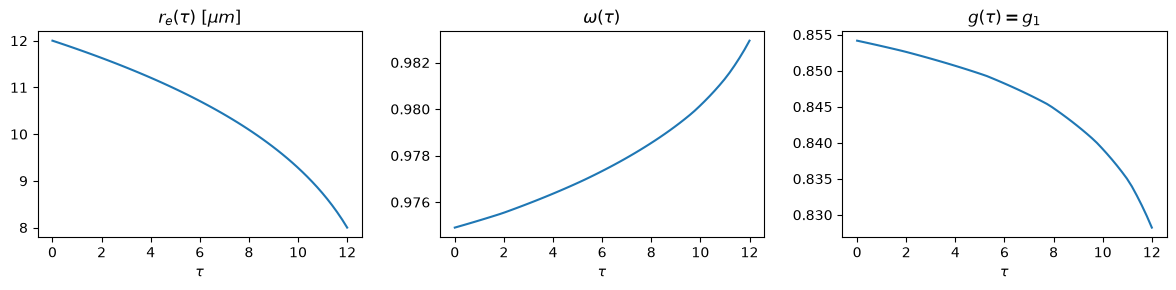

In [2]:
wavelength, v_eff = 2.13, 0.10           # MODIS band 7 (microns), gamma width

tau_bot = 12.0
NQuad, NLeg, NLeg_all = 16, 16, 32       # streams; NLeg_all > NLeg feeds delta-M / TMS
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)

# Optics interpolation table r_e -> (omega, Leg_coeffs), built once (offline,
# high n_radii -> ripple-free). Full Mie inside the ODE never finishes compiling;
# the table makes the optics O(1) and keeps r_e -> (omega, Leg) differentiable
# (table-slope Jacobian). select_channel picks the (single) MODIS band exactly.
opt = select_channel(
    build_re_table([wavelength], 2.0, 25.0, 32, v_eff, precomp, n_radii=600), 0)

# Adiabatic r_e(tau): grows from base (tau=tau_bot) to top (tau=0). The adiabatic
# law in OPTICAL DEPTH is r_e ~ tau^(1/5): r_e**3 ~ LWC ~ height z, but the
# extinction ~ r_e**2 makes tau ~ z^(5/3), so r_e ~ tau^(1/5). We make r_e**5 affine
# in tau -> r_e stays >= re_base and dr_e/dtau is finite (no root cusp at base).
re_top, re_base = 12.0, 8.0              # microns (marine Sc: gentle 12->8 um growth)
def r_e_of_tau(tau, re_top=re_top, re_base=re_base):
    return (re_base ** 5 + (re_top ** 5 - re_base ** 5) * (1 - tau / tau_bot)) ** (1 / 5)

def optics(tau, re_top=re_top, re_base=re_base):
    return table_lookup(opt, r_e_of_tau(tau, re_top, re_base))

omega_func      = lambda tau: optics(tau)[0]
Leg_coeffs_func = lambda tau: optics(tau)[1]

tau_plot = jnp.linspace(0, tau_bot, 60)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(tau_plot, [r_e_of_tau(t) for t in tau_plot]); ax[0].set_title(r'$r_e(\tau)\ [\mu m]$')
ax[1].plot(tau_plot, [omega_func(t) for t in tau_plot]); ax[1].set_title(r'$\omega(\tau)$')
ax[2].plot(tau_plot, [Leg_coeffs_func(t)[1] for t in tau_plot]); ax[2].set_title(r'$g(\tau)=g_1$')
for a in ax: a.set_xlabel(r'$\tau$')
plt.tight_layout()

## 2. Forward model: ToA radiance

Solve, then interpolate to the satellite viewing geometry. This `forward` function — radiance as a function of the profile parameters — is the object we will both evaluate and differentiate.

In [3]:
mu0, I0, phi0 = 0.6, 1.0, 0.0           # solar geometry
mu_obs, phi_obs = 0.5, pi               # viewing geometry
BDRF = [0.06]                       # ocean surface

def forward(re_top, re_base):
    om  = lambda tau: optics(tau, re_top, re_base)[0]
    Leg = lambda tau: optics(tau, re_top, re_base)[1]
    mu_arr_pos, flux_up, u0, u_func, _ = pydisort_riccati_jax(
        tau_bot, om, Leg, NQuad, mu0, I0, phi0,
        tol=1e-3, BDRF_Fourier_modes=BDRF,                    # float32-safe production tol
        delta_M_scaling=True, NLeg_all=NLeg_all, NT_cor=True)  # forward-peak fix (OUTSTANDING A)
    return interpolate(u_func, mu_arr_pos)(mu_obs, phi_obs)

I_obs = forward(re_top, re_base)
print('ToA radiance at (mu_obs, phi_obs):', float(I_obs))

ToA radiance at (mu_obs, phi_obs): 0.27201661467552185


## 3. Retrieval Jacobian via autodiff

Because the whole chain is JAX-traceable, the sensitivity of the observed radiance to the profile parameters is a single `jax.grad` — no finite differences, no perturbing the solver. This $\partial I/\partial r_e$ is the building block of the retrieval's Gauss–Newton / optimal-estimation step.

*Parameters must enter through `omega_func`/`Leg_coeffs_func`; `tau_bot`, `mu0`, `NQuad` are validated in NumPy and are not differentiable. Finite-difference validation of these gradients lives in the float64 test suite (`pytest -m float64`); in float32 a bare FD is dominated by the solver's tolerance floor, so we don't reproduce it in this demonstration.*

In [4]:
dI_dre_top, dI_dre_base = jax.grad(forward, argnums=(0, 1))(re_top, re_base)
print('dI/d(r_e top)  =', float(dI_dre_top))
print('dI/d(r_e base) =', float(dI_dre_base))

dI/d(r_e top)  = 0.015191251412034035
dI/d(r_e base) = -0.0002068690664600581


## 4. Toward a multi-band retrieval

A real retrieval stacks several MODIS bands (0.645 µm constrains $\tau$, 2.13 µm constrains $r_e$) and minimises a cost $\;J(\boldsymbol\theta)=\sum_b \lVert I_b^{\text{obs}}-F_b(\boldsymbol\theta)\rVert^2 + \text{(prior)}$ over the $r_e(\tau)$ parameters $\boldsymbol\theta$.
 The gradient $\nabla_{\boldsymbol\theta} J$ is assembled from the per-band Jacobians above via `jax.grad`, and fed to an optimiser (`jaxopt`, `optax`, or a hand-rolled Gauss–Newton step). Stacking bands is just building the table at several wavelengths — `build_re_table([0.645, 1.64, 2.13], …)` and `select_channel` per band; a hyperspectral instrument instead builds on a dense, uniform $\lambda$ grid and `slice_wavelength`-interpolates to each channel.

**Performance & scope notes.** The forward model's cost is dominated by the number of adaptive Riccati steps (~35 for $\tau{=}30$); loosen `tol` in the retrieval loop and tighten only for the final fit. The default float32 is adequate against VOCALS measurement noise (10–20 %); enable `jax_enable_x64` for finite-difference gradient checks. Delta-M scaling + the Nakajima–Tanaka TMS correction are **enabled here** (`delta_M_scaling=True, NT_cor=True`, with `NLeg_all=32` untruncated moments) so the forward-peaked-Mie ToA radiance stays non-negative (see [`OUTSTANDING.md`](./OUTSTANDING.md) §A); the reverse-mode Jacobian is exact AD, its memory now bounded by the `lax.scan` over Fourier modes (§H).

In [5]:
import jax
jax.clear_caches()   # free the intro cells' executables before the (memory-heavy) retrievals

import vocals_io as vio
import retrieval_oe as roe
from miejax_lite import mie_legendre_precompute, build_re_table, select_channel

DATA = ('/home/jovyan/cloud_profile_retrieval/'
        'multispectral-retrieval-using-MODIS/VOCALS_REx_data')
profiles = vio.load_all_profiles(DATA)

# common geometry / discretisation (shared by the idealized AND joint retrievals)
NQuad, NLeg_all, v_eff = 16, 128, 0.10
mu0, I0, phi0 = 0.6, 1.0, 0.0
# Use >= NQuad//2 (=8) view angles: off-node radiances are interpolations of the 8
# upwelling quadrature-node radiances, so fewer than 8 views under-samples that field
# and leaves retrievable information unused (DESIGN §11b; thin A_top 0.25->0.39, 3->8).
view_mu = np.linspace(0.95, 0.25, 8)        # 8 polar views ~18-76 deg, principal plane
view_phi = np.full(view_mu.size, pi)
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)

In [6]:
# --- shared UQ helpers: a FIXED-anchor variant (idealized, known base) and a JOINT
# variant (retrieves r_base + tau_bot). The joint state is [r_e nodes, r_base, tau_bot].

def dofs_sentence_fixed(post, m):
    return (f"DOFS = {post.dofs:.2f}, SIC = {post.sic:.1f} bits from {m} radiances: "
            f"~{post.dofs:.1f} independent features of r_e(tau) (base fixed/known); SIC is the "
            f"total information (magnitude of variance reduction, not just feature count).")

def dofs_sentence(post, m, dby):
    rb = dby['r_base']
    rb_txt = ('r_base is radiatively shielded -- the prior fills it' if rb < 0.4 else
              f'r_base is partly resolved ({rb:.2f} DOF: a thin base is optically visible)')
    return (f"DOFS = {post.dofs:.2f} (SIC = {post.sic:.1f} bits) from {m} radiances: "
            f"~{post.dofs:.1f} independent features, split profile={dby['profile']:.2f} / "
            f"r_base={dby['r_base']:.2f} / tau_bot={dby['tau_bot']:.2f}. tau_bot ~fully measured "
            f"(~1 DOF); {rb_txt}. DOFS counts features; SIC (bits) weights how sharply each is "
            f"measured -- report both.")

def joint_summary(fwd, res, post, truth, clim, sig_tau):
    k = len(res.tau_nodes)
    _, r_base_ret, tau_bot_ret = fwd._split_state(res.x, res.tau_nodes)
    r_base_ret, tau_bot_ret = float(r_base_ret), float(tau_bot_ret)
    rb_err, tb_err = float(post.error[k]), float(post.error[k + 1])
    rb_prior, tb_prior = float(res.x_a[k]), float(res.x_a[k + 1])
    rb_frac = float(post.data_fraction[k])
    rb_tag = ('shielded' if rb_frac < 0.4 else 'partly shielded'
              if rb_frac < 0.7 else 'well-constrained')
    s = np.asarray(res.tau_nodes)
    truth_at = np.interp(s * tau_bot_ret, truth.tau, truth.r_e)
    rmse = float(np.sqrt(np.mean((np.asarray(res.x[:k]) - truth_at) ** 2)))
    print(f'  tau_bot : retrieved {tau_bot_ret:6.2f}  truth {truth.tau_bot:6.2f}  '
          f'(prior {tb_prior:.1f}+-{sig_tau:.1f} -> post +-{tb_err:.2f})')
    print(f'  r_base  : retrieved {r_base_ret:6.2f}  truth {truth.r_base:6.2f}  '
          f'(prior {rb_prior:.1f} -> post +-{rb_err:.2f}, {rb_frac * 100:.0f}% '
          f'var.-reduction: {rb_tag})')
    print(f'  profile : RMSE {rmse:.2f} um on {k} nodes  '
          f'(ret {np.round(np.asarray(res.x[:k]), 2)} vs truth {np.round(truth_at, 2)})')

def _uq_panels(ax, fwd, res, post, truth, tau_bot_disp, base_pt, title, labels_extra):
    k = len(res.tau_nodes); s = np.asarray(res.tau_nodes)
    tau_ret = np.linspace(0.0, tau_bot_disp, 200)
    ax[0].plot(truth.r_e, truth.tau, '-', color='k', alpha=0.45, label='truth (in situ)')
    ax[0].plot(fwd.profile(res.x, s, tau_ret), tau_ret, '-', color='C0', lw=2, label='retrieved')
    ax[0].errorbar(np.asarray(res.x[:k]), s * tau_bot_disp, xerr=post.error[:k], fmt='o',
                   color='C0', capsize=3)
    base_pt(ax[0])
    ax[0].set_ylim(1.15 * max(tau_bot_disp, truth.tau_bot), 0)
    ax[0].set_xlabel(r'$r_e\ [\mu m]$'); ax[0].set_ylabel(r'$\tau$')
    ax[0].legend(fontsize=8); ax[0].set_title('retrieved vs in-situ truth')
    meas = np.clip(post.data_fraction, 0.0, 1.0)
    labels = [fr'$s$={si:.2f}' for si in s] + labels_extra
    yld = np.arange(len(meas))
    ax[1].barh(yld, meas, color='C0', label='from measurement')
    ax[1].barh(yld, 1 - meas, left=meas, color='0.82', label='from prior')
    for i, f in enumerate(meas):
        ax[1].text(0.5, i, f'{f * 100:.0f}%', va='center', ha='center', fontsize=8)
    ax[1].set_yticks(yld); ax[1].set_yticklabels(labels); ax[1].invert_yaxis()
    ax[1].set_xlim(0, 1); ax[1].set_xlabel('fraction of prior uncertainty removed')
    ax[1].legend(fontsize=8, loc='lower right'); ax[1].set_title('where each value comes from')
    for i in range(k):
        ax[2].plot(post.A[i][:k], s, 'o-', label=fr'$s$={s[i]:.2f}')
    ax[2].invert_yaxis(); ax[2].set_xlabel('averaging-kernel row (profile block)')
    ax[2].set_ylabel(r'normalized depth $s$'); ax[2].legend(fontsize=7)
    ax[2].set_title('averaging kernels (expert)')

def plot_uq_fixed(fwd, res, post, truth, title=""):
    # idealized: base is KNOWN (fwd.r_base at fwd.tau_bot), state = r_e nodes only
    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
    def base_pt(a):
        a.plot([fwd.r_base], [fwd.tau_bot], 'o', color='red', ms=9, zorder=5, label='known base')
    _uq_panels(ax, fwd, res, post, truth, fwd.tau_bot, base_pt, title, [])
    fig.suptitle(title, fontsize=11); plt.tight_layout()

def plot_uq(fwd, res, post, truth, title=""):
    # joint: base + tau_bot RETRIEVED (with error bars); prior drawn on its own tau_bot
    k = len(res.tau_nodes); s = np.asarray(res.tau_nodes)
    _, r_base_ret, tau_bot_ret = fwd._split_state(res.x, s)
    r_base_ret, tau_bot_ret = float(r_base_ret), float(tau_bot_ret)
    tau_bot_pr = float(fwd._split_state(res.x_a, s)[2])
    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
    tau_pr = np.linspace(0.0, tau_bot_pr, 200)
    ax[0].plot(fwd.profile(res.x_a, s, tau_pr), tau_pr, '--', color='C1', alpha=0.7,
               label=fr'prior ($\tau_b$={tau_bot_pr:.1f})')
    def base_pt(a):
        a.errorbar([r_base_ret], [tau_bot_ret], xerr=[float(post.error[k])],
                   yerr=[float(post.error[k + 1])], fmt='s', color='C0', capsize=4,
                   label=r'retrieved base $\pm1\sigma$')
        a.plot([truth.r_base], [truth.tau_bot], 'X', color='red', ms=12, zorder=5, label='truth base')
    _uq_panels(ax, fwd, res, post, truth, tau_bot_ret, base_pt, title,
               [r'$r_{base}$', r'$\tau_{bot}$'])
    fig.suptitle(title, fontsize=11); plt.tight_layout()

## 5. Idealized retrieval: $r_e(\tau)$ with a **known** cloud base

The original proof-of-concept and the cleanest baseline: retrieve **only** the
$r_e(\tau)$ profile, taking the cloud base $(\tau_{\rm bot},\,r_e(\tau_{\rm bot}))$ as
**known** from the in-situ truth. This isolates the profile-shape retrieval from the
much harder base/depth problem. The leak-free **joint** retrieval — which also retrieves
$\tau_{\rm bot}$ and $r_{\rm base}$ from a climatological prior — follows in §6. We show
both a thin (RF11, $\tau\!\approx\!1.2$) and a thick (RF03, $\tau\!\approx\!23$) cloud.
Everything reuses the differentiable Riccati forward, the QRCP normalized-depth grid, and
the Bayesian–Tikhonov adiabatic prior (here truth-anchored, since the base is known).

In [7]:
def idealized_retrieve(flight, target_tau, bands, k_active):
    # KNOWN-base retrieval: retrieve_*=False, tau_bot/r_base fixed from truth; truth-anchored
    # adiabatic prior (r_top prior = truth.r_top). State = r_e nodes only.
    truth = vio.pick_profile([p for p in profiles if p.flight == flight], target_tau)
    ob = [select_channel(build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp, n_radii=600), i)
          for i in range(len(bands))]
    fwd = roe.RetrievalForward(ob, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
                               tau_bot=truth.tau_bot, r_base=truth.r_base,
                               view_mu=view_mu, view_phi=view_phi,
                               BDRF_bands=[[0.06]] * len(bands), NLeg_all=NLeg_all,
                               jac_mode='fwd')  # fixed anchor (idealized known base)
    s_ref = np.linspace(0.0, 1.0, 5)[:-1]
    x_ref, _ = roe.make_adiabatic_prior(s_ref, 1.0, truth.r_base, truth.r_top)
    roe.select_num_modes(fwd, x_ref, s_ref, (0.005 ** 2) * np.eye(fwd.m))
    y = roe.osse_observation(fwd, truth.tau, truth.r_e)
    Se = np.diag((0.03 * np.maximum(np.abs(y), 0.02)) ** 2)
    s_coarse = np.linspace(0.0, 1.0, 6)[:-1]
    x0, _ = roe.make_adiabatic_prior(s_coarse, 1.0, truth.r_base, truth.r_top)
    s_grid, _, _ = roe.select_retrieval_grid(fwd, x0, s_coarse, k_active)
    prior_builder = lambda sn: roe.make_adiabatic_prior(
        sn, 1.0, truth.r_base, truth.r_top, sigma_top=3.0, sigma_base=10.0)
    x_a, Sa = prior_builder(s_grid)
    res = roe.gauss_newton_oe(fwd, y, s_grid, x_a, Sa, Se, n_iter=12, lm=1e-2, xtol=2e-3,
                              n_outer=2, k_active=k_active, prior_builder=prior_builder)
    post = roe.posterior_diagnostics(res.K, res.Sa, res.Se)
    truth_at = np.interp(np.asarray(res.tau_nodes) * fwd.tau_bot, truth.tau, truth.r_e)
    print(f'{flight} (idealized, known base tau_bot={truth.tau_bot:.2f}, r_base={truth.r_base:.2f}): '
          f'cost {res.cost_history[0]:.1e}->{res.cost_history[-1]:.1e}, ||y-F||='
          f'{np.linalg.norm(res.y - res.Fx):.1e}')
    print(f'   retrieved={np.round(res.x, 2)} vs truth={np.round(truth_at, 2)}  '
          f'(RMSE {np.sqrt(np.mean((res.x - truth_at) ** 2)):.2f} um)')
    print('   ' + dofs_sentence_fixed(post, fwd.m))
    return fwd, res, post, truth

import jax
jax.clear_caches()
fwd_i, res_i, post_i, truth_i = idealized_retrieve('RF11', 1.0, [1.24, 2.13], 4)
jax.clear_caches()
fwd_iT, res_iT, post_iT, truth_iT = idealized_retrieve('RF03', 23.3, [1.24, 1.64, 2.13], 5)

RF11 (idealized, known base tau_bot=1.21, r_base=6.33): cost 3.6e+00->4.5e-02, ||y-F||=1.3e-03
   retrieved=[8.36 8.4  8.47 7.28] vs truth=[7.77 8.07 8.47 7.02]  (RMSE 0.36 um)
   DOFS = 2.01, SIC = 7.1 bits from 16 radiances: ~2.0 independent features of r_e(tau) (base fixed/known); SIC is the total information (magnitude of variance reduction, not just feature count).


RF03 (idealized, known base tau_bot=23.26, r_base=6.45): cost 3.7e+01->6.8e-01, ||y-F||=1.3e-02
   retrieved=[11.16  9.99  8.95  8.47  8.14] vs truth=[11.41  9.36  9.34  8.98  8.44]  (RMSE 0.44 um)
   DOFS = 3.01, SIC = 9.2 bits from 24 radiances: ~3.0 independent features of r_e(tau) (base fixed/known); SIC is the total information (magnitude of variance reduction, not just feature count).


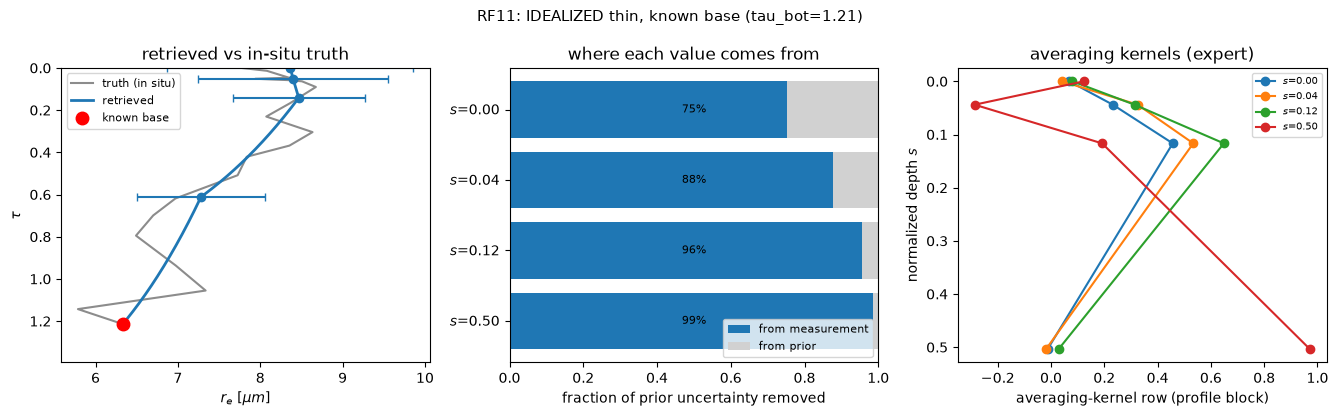

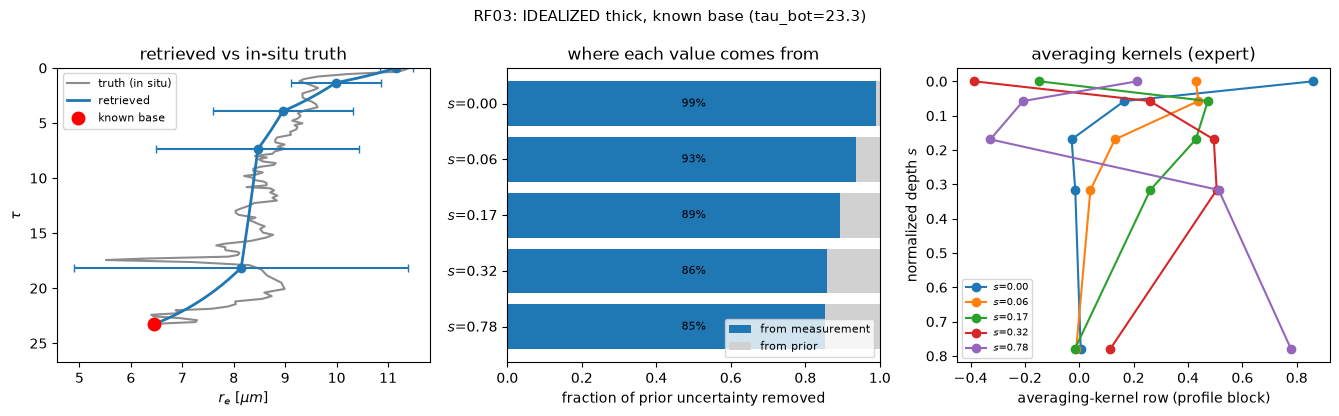

In [8]:
plot_uq_fixed(fwd_i, res_i, post_i, truth_i,
              title=f'{truth_i.flight}: IDEALIZED thin, known base (tau_bot={truth_i.tau_bot:.2f})')
plot_uq_fixed(fwd_iT, res_iT, post_iT, truth_iT,
              title=f'{truth_iT.flight}: IDEALIZED thick, known base (tau_bot={truth_iT.tau_bot:.1f})')

## 6. The leak-free **joint** retrieval (thin cloud)

Now the realistic problem: retrieve the full state
$\theta=[\,r_e(\text{nodes}),\,r_{\rm base},\,\tau_{\rm bot}\,]$ — the cloud base is
**no longer known**. Every prior mean comes from a *leave-one-flight-out* VOCALS
climatology (`vocals_climatology`, robust median+MAD, **excluding the target's flight**),
never the truth. Nodes live at **normalized depth** $s=\tau/\tau_{\rm bot}\in[0,1]$ so
they stretch with the retrieved $\tau_{\rm bot}$ (`DESIGN_DECISIONS.md` §10a). We start
thin (RF11); §13 does thick (RF03).

In [9]:
import jax
jax.clear_caches()
truth = vio.pick_profile(profiles, target_tau=1.0)
clim = vio.vocals_climatology(profiles, exclude_flight=truth.flight)
assert truth.flight not in clim['flights'], 'LEAK: target flight in climatology'
print(f'{truth.flight}: tau_bot={truth.tau_bot:.2f}, r_base={truth.r_base:.2f}, '
      f'r_top={truth.r_top:.2f}, r_e {truth.r_e.min():.1f}-{truth.r_e.max():.1f} um')
print(f'LOO climatology (n={clim["n"]}, {truth.flight} held out): '
      f'r_top={clim["r_top_mean"]:.1f}+-{clim["r_top_std"]:.1f}, '
      f'r_base={clim["r_base_mean"]:.1f}+-{clim["r_base_std"]:.1f}, '
      f'tau_bot={clim["tau_bot_mean"]:.1f}+-{clim["tau_bot_std"]:.1f}')

RF11: tau_bot=1.21, r_base=6.33, r_top=7.77, r_e 5.8-8.7 um
LOO climatology (n=110, RF11 held out): r_top=9.6+-2.7, r_base=5.7+-1.4, tau_bot=10.6+-9.5


## 7. Multi-band joint forward model + the **grounded** marine-Sc prior

A weak→strong absorption ladder (1.24→2.13 µm) carries the $r_e$-vertical information;
multiple view angles add angular leverage. The forward is built in **joint mode**. The
prior is `make_marine_sc_prior` — grounded in the VOCALS distributions, the literature, and
the prior-sensitivity study (`DESIGN_DECISIONS.md` §11): **tight where the measurement is
blind** (r_base $\approx0.65\,r_{\rm top}$, $\sigma\!\approx\!1.4$, clipped $<r_{\rm top}$),
**loose where it is strong** (r_top moderate, $\tau_{\rm bot}$ uninformative). This replaces
the earlier inverted hand-picked prior.

In [10]:
bands = [1.24, 2.13]
opt_bands = [select_channel(build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp, n_radii=600), i)
             for i in range(len(bands))]
prior_builder = lambda sn: roe.make_marine_sc_prior(
    sn, r_top_prior=clim['r_top_mean'], tau_bot_prior=clim['tau_bot_mean'])
sig_tau = float(clim['tau_bot_mean'])     # uninformative tau_bot prior (~100% relative)

fwd = roe.RetrievalForward(
    opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=clim['tau_bot_mean'], r_base=clim['r_base_mean'],   # leak-free first guess
    view_mu=view_mu, view_phi=view_phi, BDRF_bands=[[0.06]] * len(bands), NLeg_all=NLeg_all,
    retrieve_tau_bot=True, retrieve_r_base=True, jac_mode='fwd')

s_ref = np.linspace(0.0, 1.0, 5)[:-1]
x_ref, _ = prior_builder(s_ref)
K = roe.select_num_modes(fwd, x_ref, s_ref, (0.005 ** 2) * np.eye(fwd.m))
print(f'{len(bands)} bands x {view_mu.size} angles = {fwd.m} observations; '
      f'grounded prior x_a={np.round(x_ref, 2)}; S_eps modes K={K}')

2 bands x 8 angles = 16 observations; grounded prior x_a=[ 9.57  9.11  8.52  7.7   6.22 10.59]; S_eps modes K=[8, 8]


## 8. OSSE observation $y=F(x_{\rm true})$

In [11]:
y = roe.osse_observation(fwd, truth.tau, truth.r_e)
Se = np.diag((0.03 * np.maximum(np.abs(y), 0.02)) ** 2)
print('observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]')
print(np.round(y.reshape(len(bands), view_mu.size), 4))
assert np.all(y > 0), 'unphysical (negative) reflectance'

observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]
[[0.1311 0.1672 0.1691 0.2787 0.3047 0.2666 0.2666 0.293 ]
 [0.1167 0.1651 0.1964 0.2472 0.2797 0.291  0.2722 0.2932]]


## 9. Retrieval grid (normalized depth) + how many nodes? (SO1)

QRCP-ranked subset of the solver's adaptive $\tau$-pool, in normalized depth.
`auto_k_active` gives two independent node-count estimators (the filter-factor count and
$\text{round}(\text{factor}\cdot\text{DOFS})$); their agreement ($\Sigma f_i\approx$ DOFS)
is a robustness check on DOFS.

In [12]:
s_coarse = np.linspace(0.0, 1.0, 6)[:-1]
x_fg, _ = prior_builder(s_coarse)
k_active = 4
s_grid, _, info = roe.select_retrieval_grid(fwd, x_fg, s_coarse, k_active)
print(f'ODE pool {info["s_pool"].size} -> QRCP {k_active} nodes in s = {np.round(s_grid, 3)}')
Sa_pool = roe.make_adiabatic_prior(info['s_pool'], 1.0, 0.65 * clim['r_top_mean'],
                                   clim['r_top_mean'], sigma_top=2.5, sigma_base=1.5)[1]
k_f, if_f = roe.auto_k_active(info['K_pool'], Se, Sa_pool, method='filter')
k_d, if_d = roe.auto_k_active(info['K_pool'], Se, Sa_pool, method='dofs', factor=1.5)
agree = abs(if_f['sum_filter_factor'] - if_f['dofs']) / if_f['dofs'] * 100
print(f"SO1 auto_k: filter->{k_f} (Sum f_i={if_f['sum_filter_factor']:.2f}), dofs->{k_d} "
      f"(DOFS={if_d['dofs']:.2f}); agree to {agree:.0f}% -> DOFS robust")

ODE pool 20 -> QRCP 4 nodes in s = [0.    0.061 0.175 0.517]
SO1 auto_k: filter->5 (Sum f_i=3.55), dofs->4 (DOFS=2.79); agree to 27% -> DOFS robust


## 10. Optimal estimation with a structural-misfit re-mesh gate (SO2b)

Rodgers Gauss–Newton, exact reverse-mode Jacobian, projected (clamped) steps. The outer
re-mesh loop is **gated** on a persistently high reduced-$\chi^2$ — re-mesh only on a
structural misfit, not when a well-fit correlated basis would just churn placement.

In [13]:
x_a, Sa = prior_builder(s_grid)
res = roe.gauss_newton_oe(fwd, y, s_grid, x_a, Sa, Se, n_iter=12, lm=1e-2, xtol=2e-3,
                          n_outer=2, k_active=k_active, prior_builder=prior_builder,
                          remesh_if_chi2_red_gt=2.0)
remeshed = not (len(res.tau_nodes) == len(s_grid)
                and np.allclose(res.tau_nodes, s_grid, atol=1e-3))
print(f'converged={res.converged}, cost {res.cost_history[0]:.2e}->{res.cost_history[-1]:.2e}, '
      f'||y-F||={np.linalg.norm(res.y - res.Fx):.2e}')
print(f'final grid s={np.round(res.tau_nodes, 3)} '
      f'(re-mesh {"applied" if remeshed else "skipped by chi2 gate"})')

converged=True, cost 2.31e+04->5.71e-01, ||y-F||=1.20e-03
final grid s=[0.    0.061 0.175 0.517] (re-mesh skipped by chi2 gate)


## 11. Uncertainty quantification — and the PO answer

`dofs_by_component` splits the DOFS into profile / $r_{\rm base}$ / $\tau_{\rm bot}$, and
`posterior_diagnostics` now also returns the scalar **SIC** (bits). Making $\tau_{\rm bot}$
unknown costs almost nothing — it is measured to ~1 DOF and its $\sigma$ collapses to ~0.03.
With the **grounded prior**, $r_{\rm base}$ is **prior-dominated** (~21 % variance reduction,
DOFS$\approx$0.06): the tight, data-grounded microphysical prior ($r_{\rm base}\approx
0.65\,r_{\rm top}$, $\sigma\approx$1.4 µm) does the work — and because that prior mean (~6.2 µm)
is close to truth (6.3 µm), the retrieved base is accurate *without* relying on the measurement.
This is the "tight where the measurement is weak" design working as intended, not a failure to
measure; the measurement's *intrinsic* ability to constrain the thin base (with a deliberately
loosened prior) is exercised in §13. The middle panel shows the per-element split (profile nodes
~70–90 % measured, $\tau_{\rm bot}$ 100 %, $r_{\rm base}$ ~20 %); the profile panel shows the
prior's own (wrong, $\tau_b\!\approx\!10.6$) depth collapsing onto the truth depth ~1.2.

retrieval 1-sigma = [1.29 0.89 0.81 0.64 1.34 0.03]   [r_e nodes, r_base, tau_bot]
  tau_bot : retrieved   1.21  truth   1.21  (prior 10.6+-10.6 -> post +-0.03)
  r_base  : retrieved   5.86  truth   6.33  (prior 6.2 -> post +-1.34, 21% var.-reduction: shielded)
  profile : RMSE 0.52 um on 4 nodes  (ret [8.71 8.54 8.22 7.41] vs truth [7.77 8.57 8.16 6.94])
DOFS = 2.86 (SIC = 13.6 bits) from 16 radiances: ~2.9 independent features, split profile=1.80 / r_base=0.06 / tau_bot=1.00. tau_bot ~fully measured (~1 DOF); r_base is radiatively shielded -- the prior fills it. DOFS counts features; SIC (bits) weights how sharply each is measured -- report both.


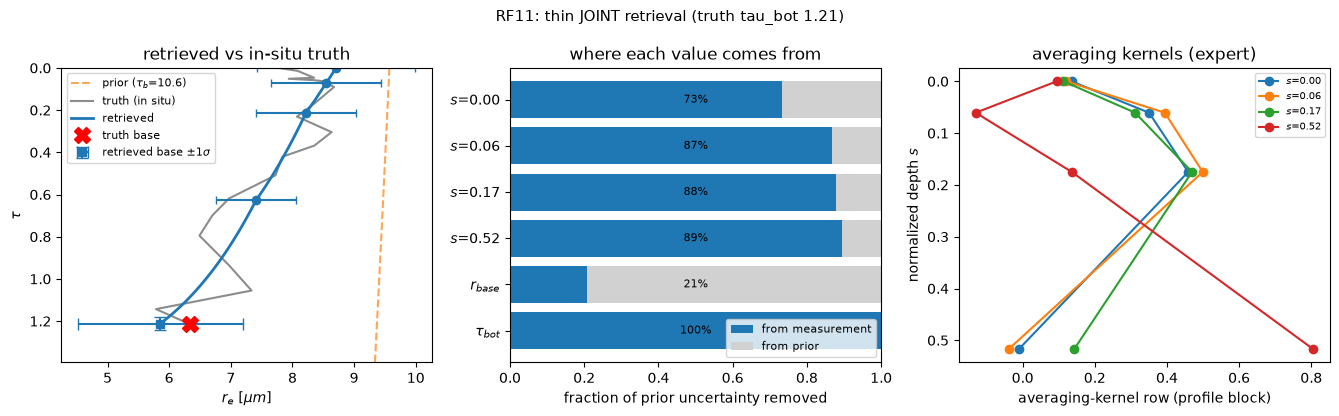

In [14]:
post = roe.posterior_diagnostics(res.K, res.Sa, res.Se)
dby = roe.dofs_by_component(post, len(res.tau_nodes), retrieve_r_base=True, retrieve_tau_bot=True)
print('retrieval 1-sigma =', np.round(post.error, 2), '  [r_e nodes, r_base, tau_bot]')
joint_summary(fwd, res, post, truth, clim, sig_tau)
print(dofs_sentence(post, fwd.m, dby))
plot_uq(fwd, res, post, truth, title=f'{truth.flight}: thin JOINT retrieval (truth tau_bot {truth.tau_bot:.2f})')

## 12. A thick, non-adiabatic cloud ($\tau\approx23$) — joint retrieval

VOCALS-REx **RF03**: the LOO $\tau_{\rm bot}$ prior ($\approx10$) is less than half the
truth, so the joint retrieval must **pull $\tau_{\rm bot}$ up** from the multi-band
reflectance, while the base is now radiatively shielded (its $r_e$ stays prior-driven —
the grounded prior pins it at the adiabatic value). A third band (1.64 µm) adds vertical
leverage; the grid is selected once ($n_{\rm outer}=1$).

In [15]:
import jax
jax.clear_caches()
thick = vio.pick_profile([p for p in profiles if p.flight == 'RF03'], target_tau=23.3)
climT = vio.vocals_climatology(profiles, exclude_flight=thick.flight)
bandsT = [1.24, 1.64, 2.13]
opt_bandsT = [select_channel(build_re_table(bandsT, 2.0, 25.0, 32, v_eff, precomp, n_radii=600), i)
              for i in range(len(bandsT))]
prior_builderT = lambda sn: roe.make_marine_sc_prior(
    sn, r_top_prior=climT['r_top_mean'], tau_bot_prior=climT['tau_bot_mean'])
sig_tauT = float(climT['tau_bot_mean'])
fwdT = roe.RetrievalForward(opt_bandsT, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
                            tau_bot=climT['tau_bot_mean'], r_base=climT['r_base_mean'],
                            view_mu=view_mu, view_phi=view_phi, BDRF_bands=[[0.06]] * len(bandsT),
                            NLeg_all=NLeg_all, retrieve_tau_bot=True, retrieve_r_base=True, jac_mode='fwd')
s_refT = np.linspace(0.0, 1.0, 6)[:-1]
x_refT, _ = prior_builderT(s_refT)
KT = roe.select_num_modes(fwdT, x_refT, s_refT, (0.005 ** 2) * np.eye(fwdT.m))
yT = roe.osse_observation(fwdT, thick.tau, thick.r_e)
SeT = np.diag((0.03 * np.maximum(np.abs(yT), 0.02)) ** 2)
k_activeT = 5
s_gridT, _, _ = roe.select_retrieval_grid(fwdT, x_refT, s_refT, k_activeT)
print(f'{thick.flight}: tau_bot={thick.tau_bot:.1f} (LOO prior {climT["tau_bot_mean"]:.1f}); '
      f'{fwdT.m} obs, modes K={KT}; QRCP s={np.round(s_gridT, 3)}')

RF03: tau_bot=23.3 (LOO prior 10.2); 24 obs, modes K=[8, 8, 8]; QRCP s=[0.    0.071 0.243 0.415 0.536]


cost 2.34e+02->2.07e+00, ||y-F||=1.63e-02  (measurement corrects the prior)
  tau_bot : retrieved  22.40  truth  23.26  (prior 10.2+-10.2 -> post +-0.46)
  r_base  : retrieved   6.14  truth   6.45  (prior 6.2 -> post +-1.40, 13% var.-reduction: shielded)
  profile : RMSE 0.46 um on 5 nodes  (ret [11.05  9.94  8.73  8.33  8.13] vs truth [11.41  9.51  9.23  8.38  8.83])
DOFS = 3.22 (SIC = 11.0 bits) from 24 radiances: ~3.2 independent features, split profile=2.20 / r_base=0.03 / tau_bot=1.00. tau_bot ~fully measured (~1 DOF); r_base is radiatively shielded -- the prior fills it. DOFS counts features; SIC (bits) weights how sharply each is measured -- report both.


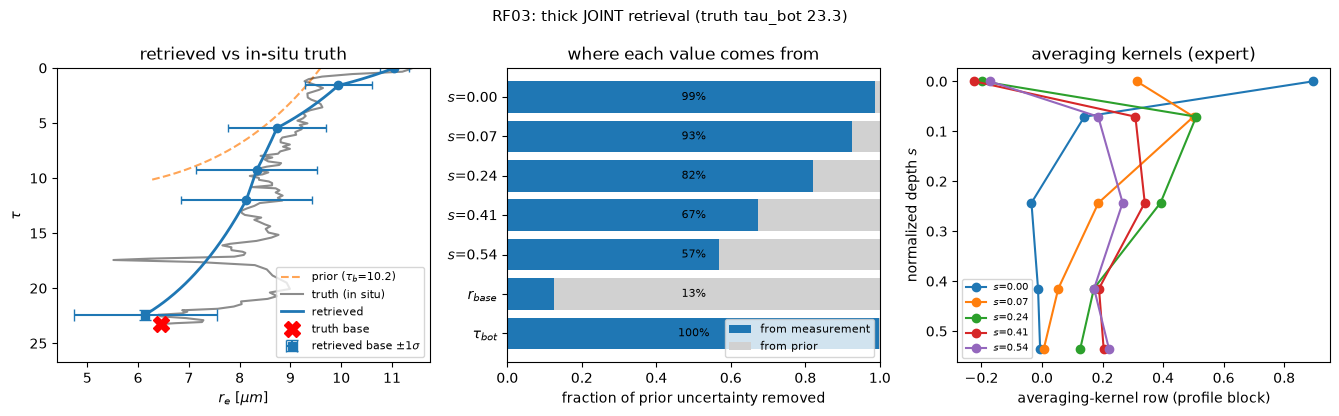

In [16]:
x_aT, SaT = prior_builderT(s_gridT)
resT = roe.gauss_newton_oe(fwdT, yT, s_gridT, x_aT, SaT, SeT, n_iter=15, lm=1e-2, xtol=5e-3,
                           n_outer=1)
postT = roe.posterior_diagnostics(resT.K, resT.Sa, resT.Se)
dbyT = roe.dofs_by_component(postT, len(resT.tau_nodes), retrieve_r_base=True, retrieve_tau_bot=True)
print(f'cost {resT.cost_history[0]:.2e}->{resT.cost_history[-1]:.2e}, '
      f'||y-F||={np.linalg.norm(resT.y - resT.Fx):.2e}  (measurement corrects the prior)')
joint_summary(fwdT, resT, postT, thick, climT, sig_tauT)
print(dofs_sentence(postT, fwdT.m, dbyT))
plot_uq(fwdT, resT, postT, thick, title=f'{thick.flight}: thick JOINT retrieval (truth tau_bot {thick.tau_bot:.1f})')

## 13. Detecting a sub-adiabatic (re-evaporating) base — where is it possible?

A *sub-adiabatic* base — $r_e$ dropping toward cloud bottom **below** the adiabatic
extrapolation of the upper cloud — is the microphysical signature of sub-saturation /
drizzle re-evaporation. The grounded prior (§7) deliberately pins $r_{\rm base}$ at the
adiabatic value, which would *mask* such an anomaly; so here we switch to a **detection
prior** — same adiabatic mean but a **loosened** $r_{\rm base}\ \sigma$ — to isolate what
the *measurement* can reveal. We test two real profiles with a near-base drop below
adiabatic: **RF03 $\tau\!\approx\!1.5$** (thin, base optically visible) and **RF10
$\tau\!\approx\!4.9$** (the sharpest drop, but partly shielded). The discriminator is
*where* the structure sits relative to photon penetration, not $\tau$ alone. (The VOCALS
data floor is $\tau\!\approx\!1.2$, so $\tau\!\lesssim\!1$ — where a near-bottom drop might
be fully recoverable — cannot be tested here.)

In [17]:
import jax
jax.clear_caches()


def subadiab_detect(flight, target_tau, bands):
    # DETECTION mode: grounded adiabatic prior MEAN, but loosened r_base sigma so the data
    # (not the prior) drives r_base. Measures how much of the true near-base drop is recovered.
    tr = vio.pick_profile([p for p in profiles if p.flight == flight], target_tau)
    cl = vio.vocals_climatology(profiles, exclude_flight=tr.flight)
    ob = [select_channel(build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp, n_radii=600), i)
          for i in range(len(bands))]
    fw = roe.RetrievalForward(ob, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
                              tau_bot=cl['tau_bot_mean'], r_base=cl['r_base_mean'],
                              view_mu=view_mu, view_phi=view_phi, BDRF_bands=[[0.06]] * len(bands),
                              NLeg_all=NLeg_all, retrieve_tau_bot=True, retrieve_r_base=True, jac_mode='fwd')
    pb = lambda sn: roe.make_marine_sc_prior(sn, r_top_prior=cl['r_top_mean'],
                                             tau_bot_prior=cl['tau_bot_mean'], sigma_base=8.0)
    yy = roe.osse_observation(fw, tr.tau, tr.r_e)
    Se_ = np.diag((0.03 * np.maximum(np.abs(yy), 0.02)) ** 2)
    sref = np.linspace(0.0, 1.0, 6)[:-1]
    roe.select_num_modes(fw, pb(sref)[0], sref, Se_)
    sg, _, _ = roe.select_retrieval_grid(fw, pb(sref)[0], sref, 5)
    xa, Sa_ = pb(sg)
    r = roe.gauss_newton_oe(fw, yy, sg, xa, Sa_, Se_, n_iter=15, lm=1e-2, xtol=2e-3, n_outer=1)
    po = roe.posterior_diagnostics(r.K, r.Sa, r.Se)
    kk = len(r.tau_nodes); s_ = np.asarray(r.tau_nodes)
    tb, rb = float(r.x[kk + 1]), float(r.x[kk])
    sd = np.linspace(0.0, 1.0, 200)
    ret = np.asarray(fw.profile(r.x, s_, sd * tb))
    pri = np.asarray(fw.profile(r.x_a, s_, sd * float(cl['tau_bot_mean'])))
    tru = np.interp(sd * tb, tr.tau, tr.r_e)
    drop_ret, drop_tru = float(ret.max() - ret[-1]), float(tru.max() - tru[-1])
    cap = drop_ret / drop_tru if drop_tru > 1e-9 else float('nan')
    return dict(tr=tr, tb=tb, tb_pr=float(cl['tau_bot_mean']), rb=rb, rb_err=float(po.error[kk]),
                sd=sd, ret=ret, pri=pri, drop_ret=drop_ret, drop_tru=drop_tru, cap=cap)


SUB = {f: subadiab_detect(f, t, b) for f, t, b in
       [('RF03', 1.53, [1.24, 1.64, 2.13]), ('RF10', 4.94, [1.24, 1.64, 2.13])]}
for f, R in SUB.items():
    v = 'DETECTED' if R['drop_ret'] > 0.3 and R['cap'] > 0.3 else 'MISSED (prior won)'
    print(f"{f} tau_bot={R['tr'].tau_bot:.2f}: near-base drop truth {R['drop_tru']:+.2f} um, "
          f"retrieved {R['drop_ret']:+.2f} um ({R['cap'] * 100:.0f}%) -> {v}; "
          f"r_base {R['rb']:.1f} (truth {R['tr'].r_base:.1f})")

RF03 tau_bot=1.53: near-base drop truth +1.32 um, retrieved +0.88 um (67%) -> DETECTED; r_base 5.9 (truth 4.9)
RF10 tau_bot=4.94: near-base drop truth +2.48 um, retrieved +4.40 um (177%) -> DETECTED; r_base 5.2 (truth 5.7)


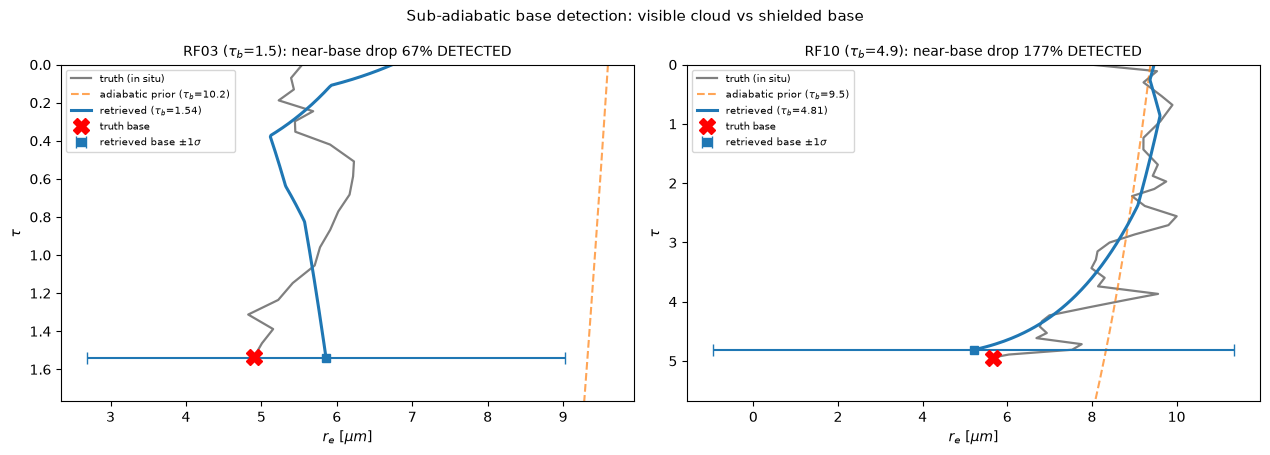

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
for ax, (f, R) in zip(axes, SUB.items()):
    tr = R['tr']
    ax.plot(tr.r_e, tr.tau, '-', color='k', alpha=0.5, lw=1.6, label='truth (in situ)')
    ax.plot(R['pri'], R['sd'] * R['tb_pr'], '--', color='C1', alpha=0.7,
            label=fr"adiabatic prior ($\tau_b$={R['tb_pr']:.1f})")
    ax.plot(R['ret'], R['sd'] * R['tb'], '-', color='C0', lw=2.2,
            label=fr"retrieved ($\tau_b$={R['tb']:.2f})")
    ax.errorbar([R['rb']], [R['tb']], xerr=[R['rb_err']], fmt='s', color='C0', capsize=4,
                label=r'retrieved base $\pm1\sigma$')
    ax.plot([tr.r_base], [tr.tau_bot], 'X', color='red', ms=12, zorder=5, label='truth base')
    ax.set_ylim(1.15 * max(R['tb'], tr.tau_bot), 0)
    ax.set_xlabel(r'$r_e\ [\mu m]$'); ax.set_ylabel(r'$\tau$')
    v = 'DETECTED' if R['drop_ret'] > 0.3 and R['cap'] > 0.3 else 'MISSED'
    ax.set_title(f"{f} ($\\tau_b$={tr.tau_bot:.1f}): near-base drop {R['cap'] * 100:.0f}% {v}", fontsize=10)
    ax.legend(fontsize=7.5)
fig.suptitle('Sub-adiabatic base detection: visible cloud vs shielded base', fontsize=11)
plt.tight_layout()

## 14. Synthesis

**Idealized vs joint (§5 vs §6–§12).** With the base **known**, $r_e(\tau)$ is retrieved
cleanly (§5; RMSE 0.36–0.44 µm). Making the base **unknown** (joint) costs little: $\tau_{\rm bot}$
is measured to ~1 DOF (thin 1.21 vs 1.21; thick 22.4 vs 23.3) and the upper-cloud profile is
recovered (RMSE 0.46–0.52 µm), while $r_{\rm base}$ is **prior-dominated** — the tight,
data-grounded prior pins it (and, being accurate, returns the right base anyway). DOFS is
**prior-dependent**; a conservative band is not worth swapping in (it saturates thick); joint
$>$ two-stage. (`DESIGN_DECISIONS.md` §10–§11.)

**The grounded prior (§7; `DESIGN` §11).** Built from VOCALS distributions + literature +
a prior-sensitivity study: **tight where the measurement is blind** ($r_{\rm base}\approx
0.65\,r_{\rm top}$, $\sigma\!\approx\!1.4$, $<r_{\rm top}$) and **loose where it is strong**
($r_{\rm top}$ moderate, $\tau_{\rm bot}$ uninformative). A *verified* mechanism: a shielded
$r_{\rm base}$ still moves only via the prior's **off-diagonal correlation** (a diagonal
prior pins it) — so its posterior is a smooth extrapolation of the observable upper cloud,
not a measurement.

**SO1 / SO2a / SO2b.** The two node-count estimators broadly agree ($\Sigma f_i$ vs DOFS to within tens of %; the tighter ~5 % agreement is in the OSSE matrix, `DESIGN` §10f) ⇒ DOFS is a usable info measure;
$r_e^5$-linear vs linear is a $<0.1$ µm second-order lever; $n_{\rm outer}=2$ re-meshing did
not help (the $\chi^2$ gate keeps it $\approx1$). (`OUTSTANDING.md` §B′, §G.)

**Top observability is angular-sampling-limited, not stream-limited.** Thick $r_{\rm top}$
is saturated (A$\approx$0.95, few streams/views); thin $r_{\rm top}$ is weakly observed
(A$\approx$0.25) and improves with **more view angles**, not more streams (A_top flat in
NQuad) — the radiance is dominated by the node-bound multiple-scatter field (single-scatter
TMS only $\sim$3 %), so few view angles *under-sample* the $N=$NQuad/2 node radiances.
**Rule: use $\geq$ NQuad/2 view angles** (here 8 at NQuad=16); fewer leaves information
unused. *Physical basis:* in a thick cloud multiple scattering drives the interior toward
the **diffusion limit**, and although ToA is never itself in the diffusion domain, the
upwelling ToA radiance is *fed by* diffusion from below — so it is smooth, moment-washed,
and node-bound; a thin cloud lacks that diffusive simplification, so its (sparse) top
information is spread across the angular field and must be sampled densely. (`DESIGN` §11b.)

**DOFS *and* SIC — report both.** The thin/thick contrast exposes a real inconsistency that
DOFS alone hides: a *thin* cloud has little depth to vary so **few DOF**, yet each is sharply
measured and it *benefits from more streams/angles* (high information density); a *thick*
cloud varies more (**more DOF**) but diffusion caps the per-stream information so it *gains
little from more streams*. DOFS $=\text{tr}(A)$ counts independent *features*; SIC
$=\tfrac12\log_2|S_a\hat S^{-1}|$ (bits) measures the *magnitude* of information (how sharply
each feature is pinned). Carrying both — now in `posterior_diagnostics` — separates "how many
things" from "how well", which a single number conflates.

**Sub-adiabatic base (§13).** With dense view angles and a deliberately *loosened* base prior,
the near-base re-evaporation drop is recoverable in the optically visible thin cloud (RF03
$\tau$=1.5, 67 % of the drop); for the deeper RF10 ($\tau$=4.9) the loosened prior **over-fits**
the weak, partly-shielded deep signal (177 %, base pulled past truth) — a caution that chasing
base anomalies by loosening the prior risks over-fitting. The operational grounded (tight) prior
instead returns the adiabatic value, the right default for the common non-evaporating case.